<a href="https://colab.research.google.com/github/sjakku-ai/DigitalTransformation/blob/main/dt_dataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Approach:

1. Load the data
2. Data Exploration
3. Data Preparation
4. Apply ML Model
5. Evaluate the ML Model
6. Create simple application

In [1]:
import requests
import zipfile
import os

zip_url = "https://gitlab.com/accredian/insaid-data/-/raw/main/Terms%202025/archive__2___1_.zip"
output_filename = "downloaded_data.zip"
extract_dir = "extracted_data"

# Download the zip file
print(f"Downloading {zip_url}...")
response = requests.get(zip_url, stream=True)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

with open(output_filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
print(f"Downloaded {output_filename}")

# Create extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
print(f"Extracting {output_filename} to {extract_dir}...")
with zipfile.ZipFile(output_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Extraction complete.")

# List contents of the extracted directory
print(f"Contents of '{extract_dir}':")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name) + '/')

# You can now inspect the listed files and choose which one to load into a pandas DataFrame or similar.
# For example, if there's a CSV file named 'data.csv' in the extracted_data directory:
# import pandas as pd
# df = pd.read_csv(os.path.join(extract_dir, 'data.csv'))
# print(df.head())

Downloaded downloaded_data.zip
Extracting downloaded_data.zip to extracted_data...
Extraction complete.
Contents of 'extracted_data':
extracted_data/Bank Customer Churn Prediction.csv


In [9]:
print("\n--- Unique Values and Cardinality ---")
for column in df.columns:
    if df[column].nunique() < 20 and df[column].dtype == 'object': # For categorical columns with few unique values
        print(f"Column '{column}': {df[column].nunique()} unique values: {df[column].unique()}")
    elif df[column].nunique() < 20 and (df[column].dtype == 'int64' or df[column].dtype == 'float64'): # For numerical columns that might be categorical codes
        print(f"Column '{column}': {df[column].nunique()} unique values: {df[column].unique()}")
    else: # For high cardinality or continuous numerical features
        print(f"Column '{column}': {df[column].nunique()} unique values (showing first 5 if many): {df[column].unique()[:5]}...")



--- Unique Values and Cardinality ---
Column 'customer_id': 10000 unique values (showing first 5 if many): [15634602 15647311 15619304 15701354 15737888]...
Column 'credit_score': 460 unique values (showing first 5 if many): [619 608 502 699 850]...
Column 'country': 3 unique values: ['France' 'Spain' 'Germany']
Column 'gender': 2 unique values: ['Female' 'Male']
Column 'age': 70 unique values (showing first 5 if many): [42 41 39 43 44]...
Column 'tenure': 11 unique values: [ 2  1  8  7  4  6  3 10  5  9  0]
Column 'balance': 6382 unique values (showing first 5 if many): [     0.    83807.86 159660.8  125510.82 113755.78]...
Column 'products_number': 4 unique values: [1 3 2 4]
Column 'credit_card': 2 unique values: [1 0]
Column 'active_member': 2 unique values: [1 0]
Column 'estimated_salary': 9999 unique values (showing first 5 if many): [101348.88 112542.58 113931.57  93826.63  79084.1 ]...
Column 'churn': 2 unique values: [1 0]


/tmp/ipykernel_371/3519674924.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='viridis')


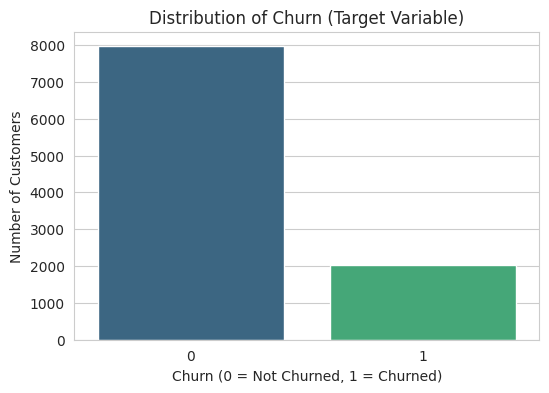


Churn Percentage:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# 1. Target Variable Distribution: 'churn'
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn (0 = Not Churned, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

churn_percentage = df['churn'].value_counts(normalize=True) * 100
print(f"\nChurn Percentage:\n{churn_percentage}")

### Observation on Target Variable:
- The dataset is imbalanced, with a significantly higher number of customers who did not churn (0) compared to those who churned (1). This is an important factor to consider for model training.

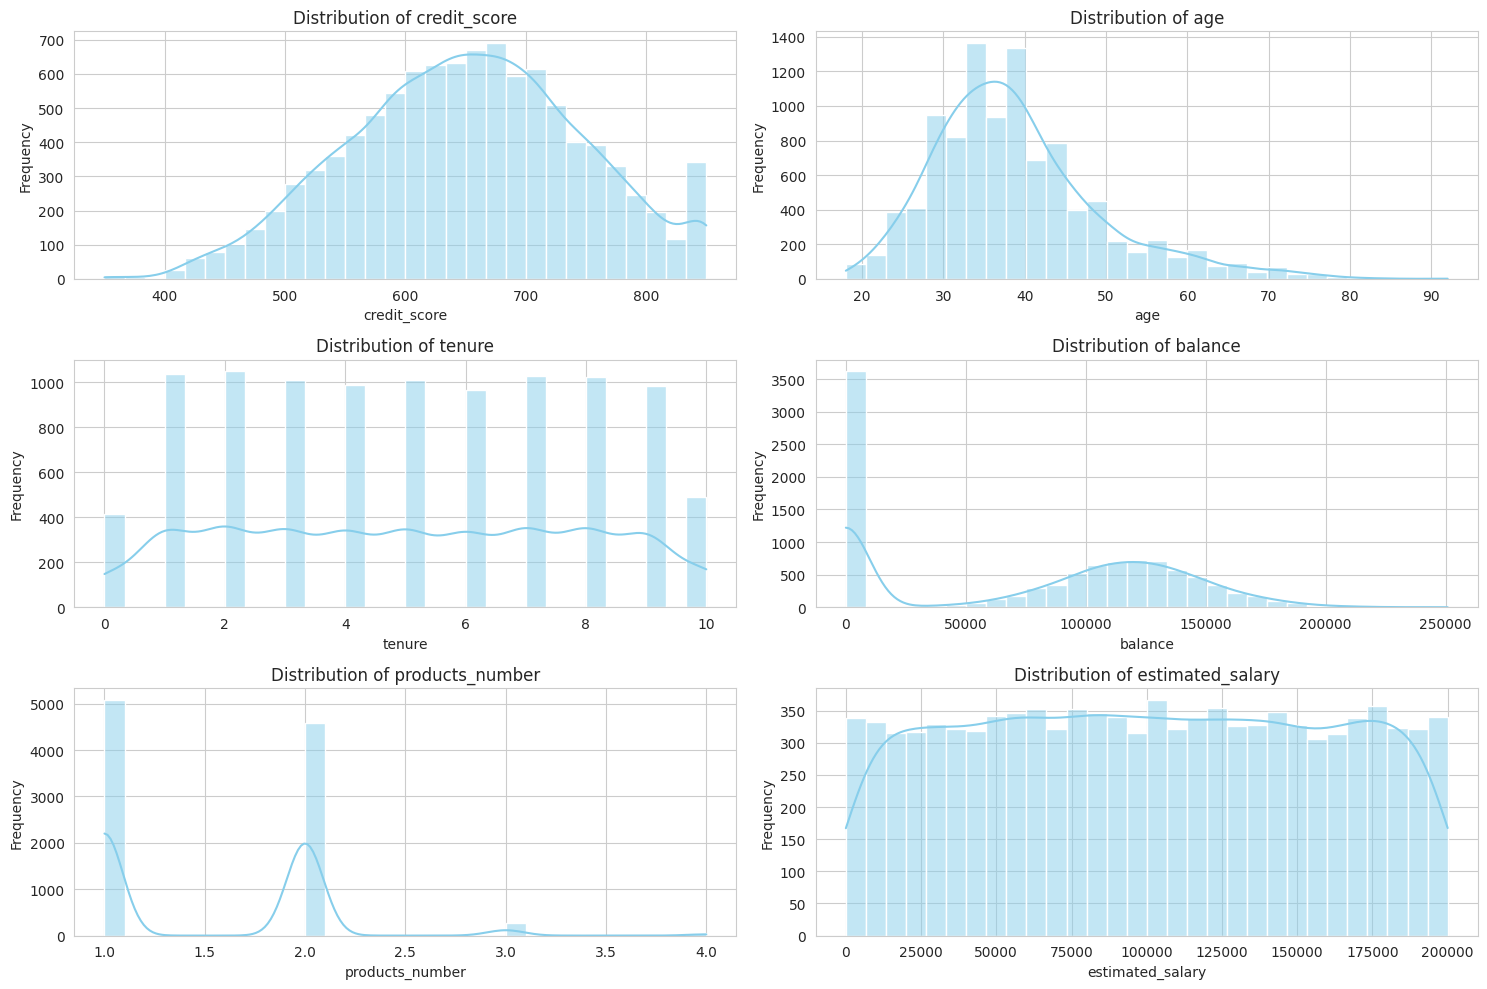

In [4]:
# 2. Distribution of Numerical Features

numerical_features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Observations on Numerical Features:
- **Credit Score**: Appears to be normally distributed, centered around 650.
- **Age**: Right-skewed, with most customers in their 20s to 40s. Fewer older customers.
- **Tenure**: Fairly uniform distribution, with some peaks at 0 and 10 years.
- **Balance**: A significant number of customers have a balance of 0, suggesting many customers don't use the bank for savings or have closed their accounts. For those with a balance, it shows a somewhat normal distribution.
- **Products Number**: Most customers have 1 or 2 products. Fewer have 3 or 4.
- **Estimated Salary**: Appears uniformly distributed, suggesting no particular pattern related to salary amount.

/tmp/ipykernel_371/3894711389.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='pastel')
/tmp/ipykernel_371/3894711389.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='pastel')
/tmp/ipykernel_371/3894711389.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='pastel')
/tmp/ipykernel_371/3894711389.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set

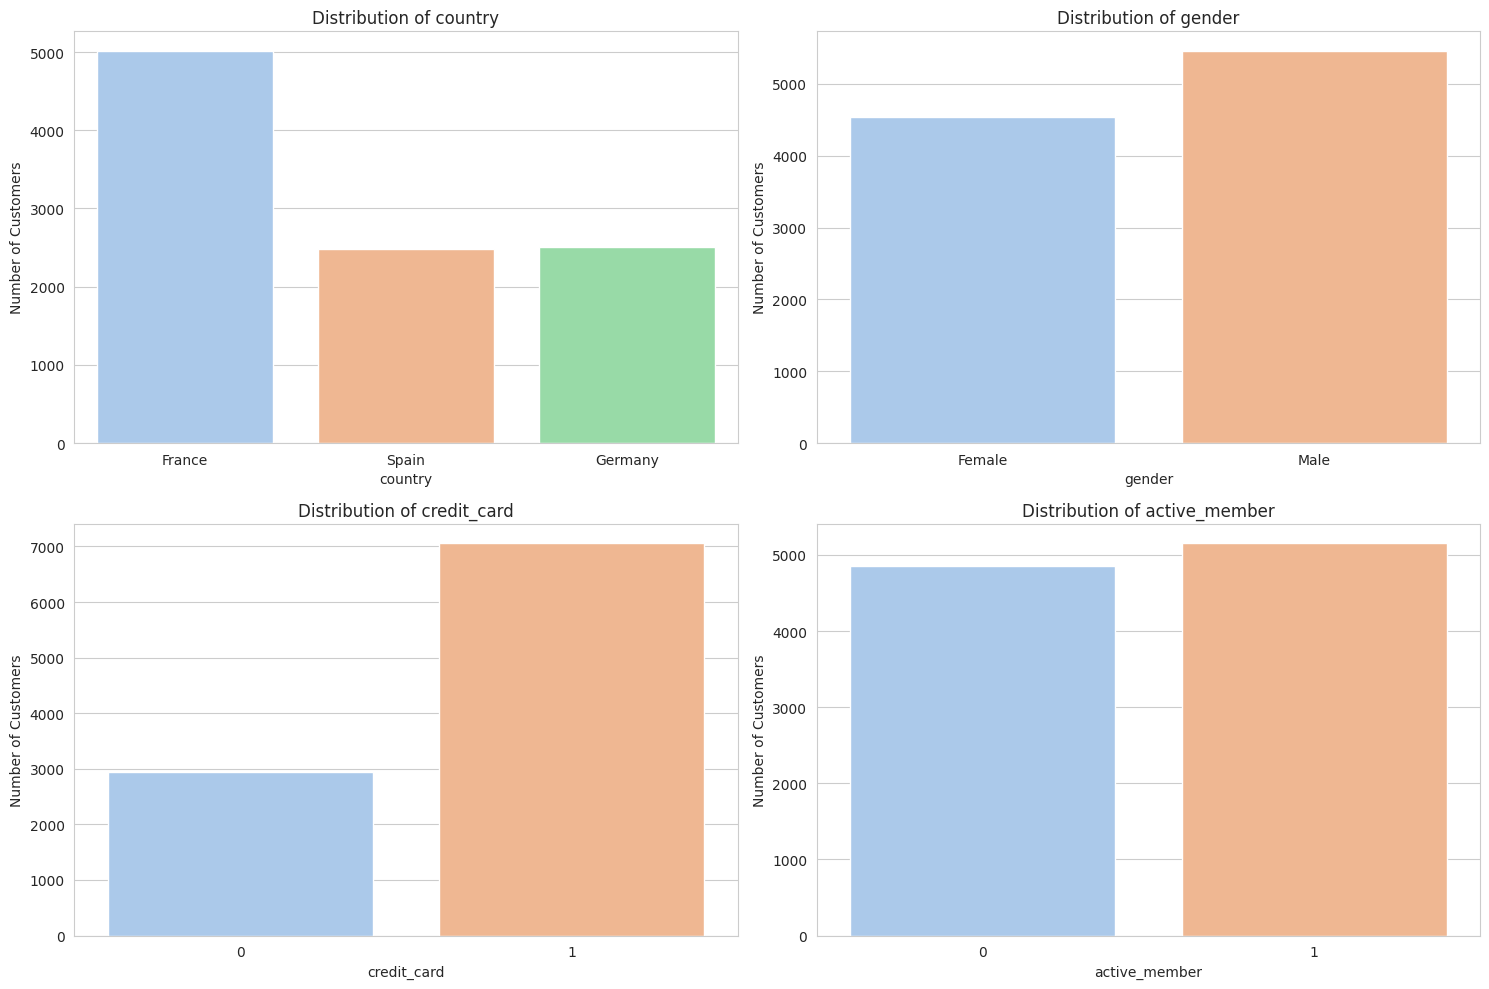

In [5]:
# 3. Distribution of Categorical Features

categorical_features = ['country', 'gender', 'credit_card', 'active_member']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, data=df, palette='pastel')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Observations on Categorical Features:
- **Country**: The majority of customers are from France, followed by Germany and Spain.
- **Gender**: The distribution between Male and Female customers is fairly balanced.
- **Credit Card**: A large majority of customers have a credit card.
- **Active Member**: The number of active and inactive members is almost equally distributed.

/tmp/ipykernel_371/559649224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y=feature, data=df, palette='muted')
/tmp/ipykernel_371/559649224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y=feature, data=df, palette='muted')
/tmp/ipykernel_371/559649224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y=feature, data=df, palette='muted')
/tmp/ipykernel_371/559649224.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

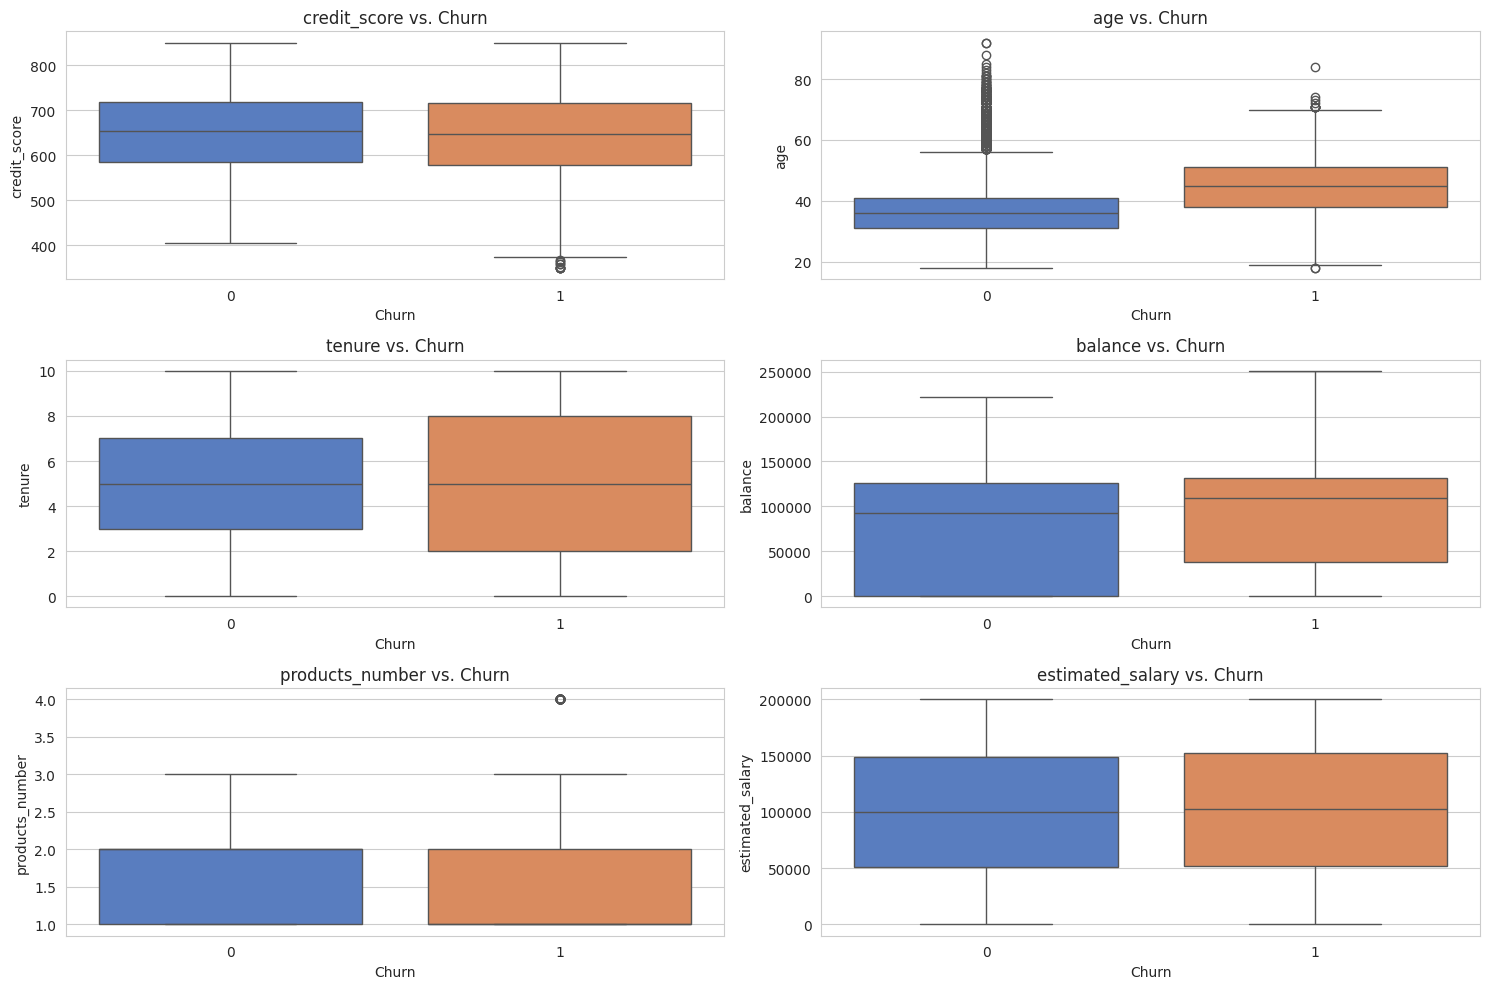

In [6]:
# 4. Relationship between Numerical Features and Churn

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x='churn', y=feature, data=df, palette='muted')
    plt.title(f'{feature} vs. Churn')
    plt.xlabel('Churn')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Observations on Numerical Features vs. Churn:
- **Credit Score**: Customers who churned tend to have slightly lower credit scores, but the difference is not very pronounced.
- **Age**: Churned customers appear to be slightly older on average, with a higher median age and a wider distribution towards older ages.
- **Tenure**: No significant visual difference in tenure between churned and non-churned customers.
- **Balance**: Customers with a balance tend to churn more, especially those with balances higher than 0. Customers with 0 balance are less likely to churn.
- **Products Number**: Customers with 3 or 4 products are much more likely to churn compared to those with 1 or 2 products.
- **Estimated Salary**: No clear pattern or significant difference in estimated salary between churned and non-churned customers.

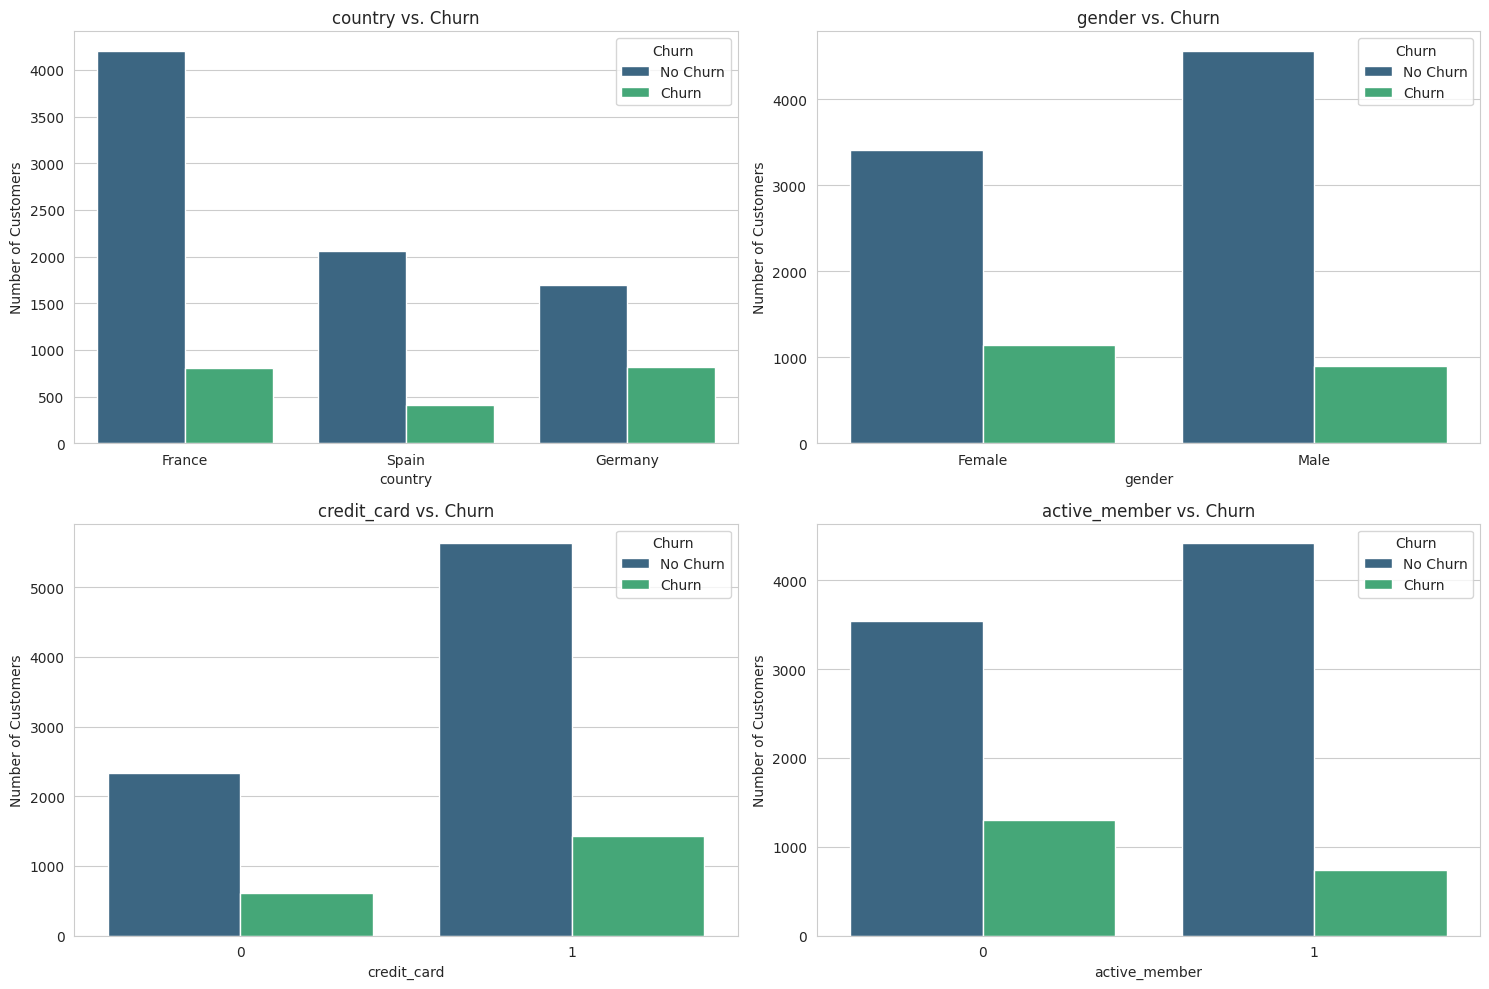

In [7]:
# 5. Relationship between Categorical Features and Churn

plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, hue='churn', data=df, palette='viridis')
    plt.title(f'{feature} vs. Churn')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')
    plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

### Observations on Categorical Features vs. Churn:
- **Country**: Germany has a higher churn rate proportionally compared to France and Spain, even though France has the most customers.
- **Gender**: Female customers seem to have a slightly higher churn rate than male customers.
- **Credit Card**: Customers with a credit card have a lower churn rate than those without one, proportionally.
- **Active Member**: Inactive members are significantly more likely to churn than active members.

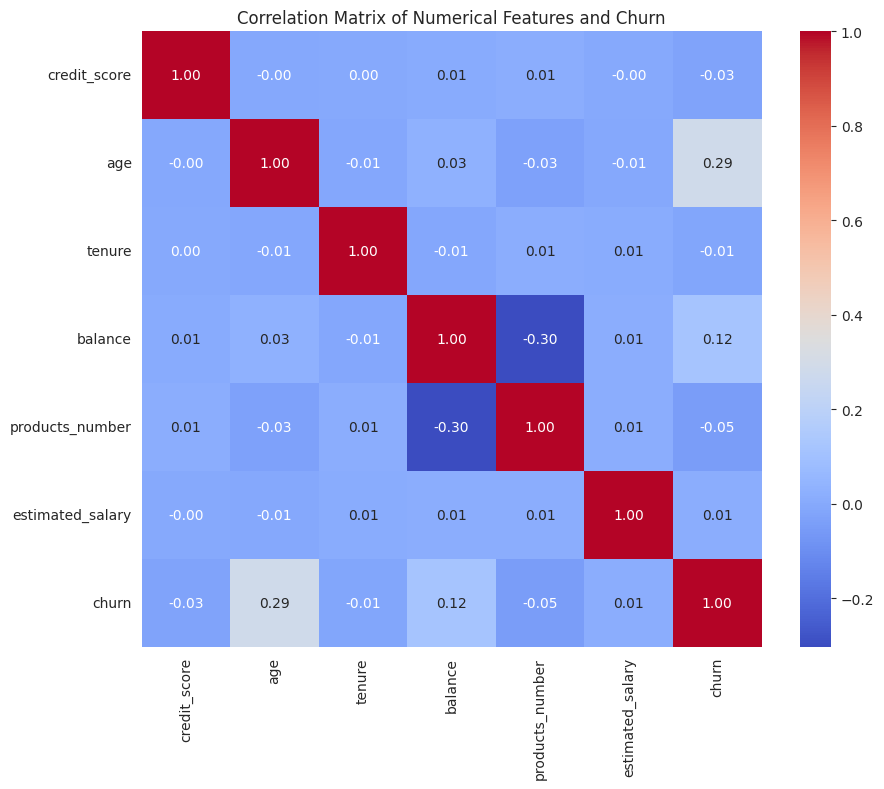

In [8]:
# 6. Correlation Matrix for Numerical Features

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features + ['churn']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features and Churn')
plt.show()

### Observations from Correlation Matrix:
- **Age** has a moderate positive correlation with **Churn**, reinforcing that older customers are more likely to churn.
- **Balance** shows a weak positive correlation with **Churn**.
- **Products Number** shows a weak positive correlation with **Churn**.
- Other numerical features like **credit_score**, **tenure**, and **estimated_salary** have very weak correlations with churn, suggesting they might not be strong direct predictors individually.

In [11]:
import pandas as pd

# Combine processed features and target variable into a single DataFrame
# X_processed_df contains the processed features
# y contains the target variable

# Ensure y is a DataFrame or Series with an aligned index to X_processed_df
processed_data_df = X_processed_df.copy()
processed_data_df['churn'] = y.values # Assigning y values, assuming they are aligned after initial split

# Save the combined DataFrame to a CSV file
output_csv_path = 'processed_churn_data.csv'
processed_data_df.to_csv(output_csv_path, index=False)

print(f"Processed data saved to '{output_csv_path}'")
print("First 5 rows of the saved data:")
print(processed_data_df.head())

Processed data saved to 'processed_churn_data.csv'
First 5 rows of the saved data:
   credit_score       age    tenure   balance  estimated_salary  \
0     -0.326221  0.293517 -1.041760 -1.225848          0.021886   
1     -0.440036  0.198164 -1.387538  0.117350          0.216534   
2     -1.536794  0.293517  1.032908  1.333053          0.240687   
3      0.501521  0.007457 -1.387538 -1.225848         -0.108918   
4      2.063884  0.388871 -1.041760  0.785728         -0.365276   

   country_France  country_Germany  country_Spain  gender_Female  gender_Male  \
0             1.0              0.0            0.0            1.0          0.0   
1             0.0              0.0            1.0            1.0          0.0   
2             1.0              0.0            0.0            1.0          0.0   
3             1.0              0.0            0.0            1.0          0.0   
4             0.0              0.0            1.0            1.0          0.0   

   products_number_1  produ